"""
Task1, Hugo(devA);
first, construct clean database;
read the data and identify the non-physical data:
    - as the diamond dimensions(x,y,z) must not be NULL or negative
    - 'carat' must be >0
    - treat 'depth' calc because could result in a division /0 if 'x + y = 0';
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================
try:
    df_train = pd.read_csv('/home/jovyan/work/AAMD-Task-SupervisedLearning/data/diamonds-train.csv')
    # Keep the original train dataframe intact for reference if needed
    df_train_clean = df_train.copy()

    # Store train IDs for the final dataframe if necessary, then drop
    train_ids = df_train_clean['id']
    df_train_clean = df_train_clean.drop(columns=['id'])

    print(f"Training data loaded successfully. Shape: {df_train_clean.shape}")
except FileNotFoundError:
    print("Error: 'diamonds-train.csv' not found. Please verify the file path.")

# ==============================================================================
# 2.IDENTIFYING "NON-PHYSICAL" DATA
# ==============================================================================
def detect_non_physical_diamonds(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies rows containing physically impossible values for a 3D object.
    Specifically checks for zero or negative values in strictly positive dimensions.
    """
    # Dimensions x, y, z must be strictly greater than 0
    mask_zero_dims = (df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)

    # Weight (carat) must be strictly greater than 0
    mask_zero_carat = (df['carat'] <= 0)

    # Combine masks to find all non-physical rows
    non_physical_mask = mask_zero_dims | mask_zero_carat

    df_non_physical = df[non_physical_mask]

    print(f"Found {len(df_non_physical)} records with non-physical data.")
    return df_non_physical, non_physical_mask


# Execute detection
df_errors, errors_mask = detect_non_physical_diamonds(df_train_clean)

# Display the erroneous rows to analyze the nature of the data corruption
if not df_errors.empty:
    display(df_errors[['carat', 'x', 'y', 'z', 'depth', 'price']])

Training data loaded successfully. Shape: (44000, 10)
Found 16 records with non-physical data.


,carat,x,y,z,depth,price
1577,1.00,0.00,0.00,0.0,63.3,5139
6555,1.12,6.71,6.67,0.0,60.4,2383
9582,2.80,8.90,8.85,0.0,63.8,18788
9858,1.56,0.00,0.00,0.0,62.2,12800
11595,1.14,0.00,0.00,0.0,57.5,6381
11837,0.71,0.00,0.00,0.0,64.1,2130
13415,1.15,6.88,6.83,0.0,59.2,5564
14807,1.00,6.55,6.48,0.0,59.1,3142
15634,0.71,0.00,0.00,0.0,64.1,2130
16397,1.01,6.66,6.60,0.0,58.1,3167


"""
there are 16 regs which show inconsistencies;
mostly 'z' dimension = 0, also, in those regs,
    the 'depth' value should be 0 due to the formula '2*z / (x + y)', this confirms data entry errors;

16/40000 represents the 0.036% of the total training set,
    so we decided to delete these rows, because try to compute the wrong data could inject unnecesary bias;
and we try to detect the outliers.
"""

Dataset shape after removing non-physical data: (43984, 10)


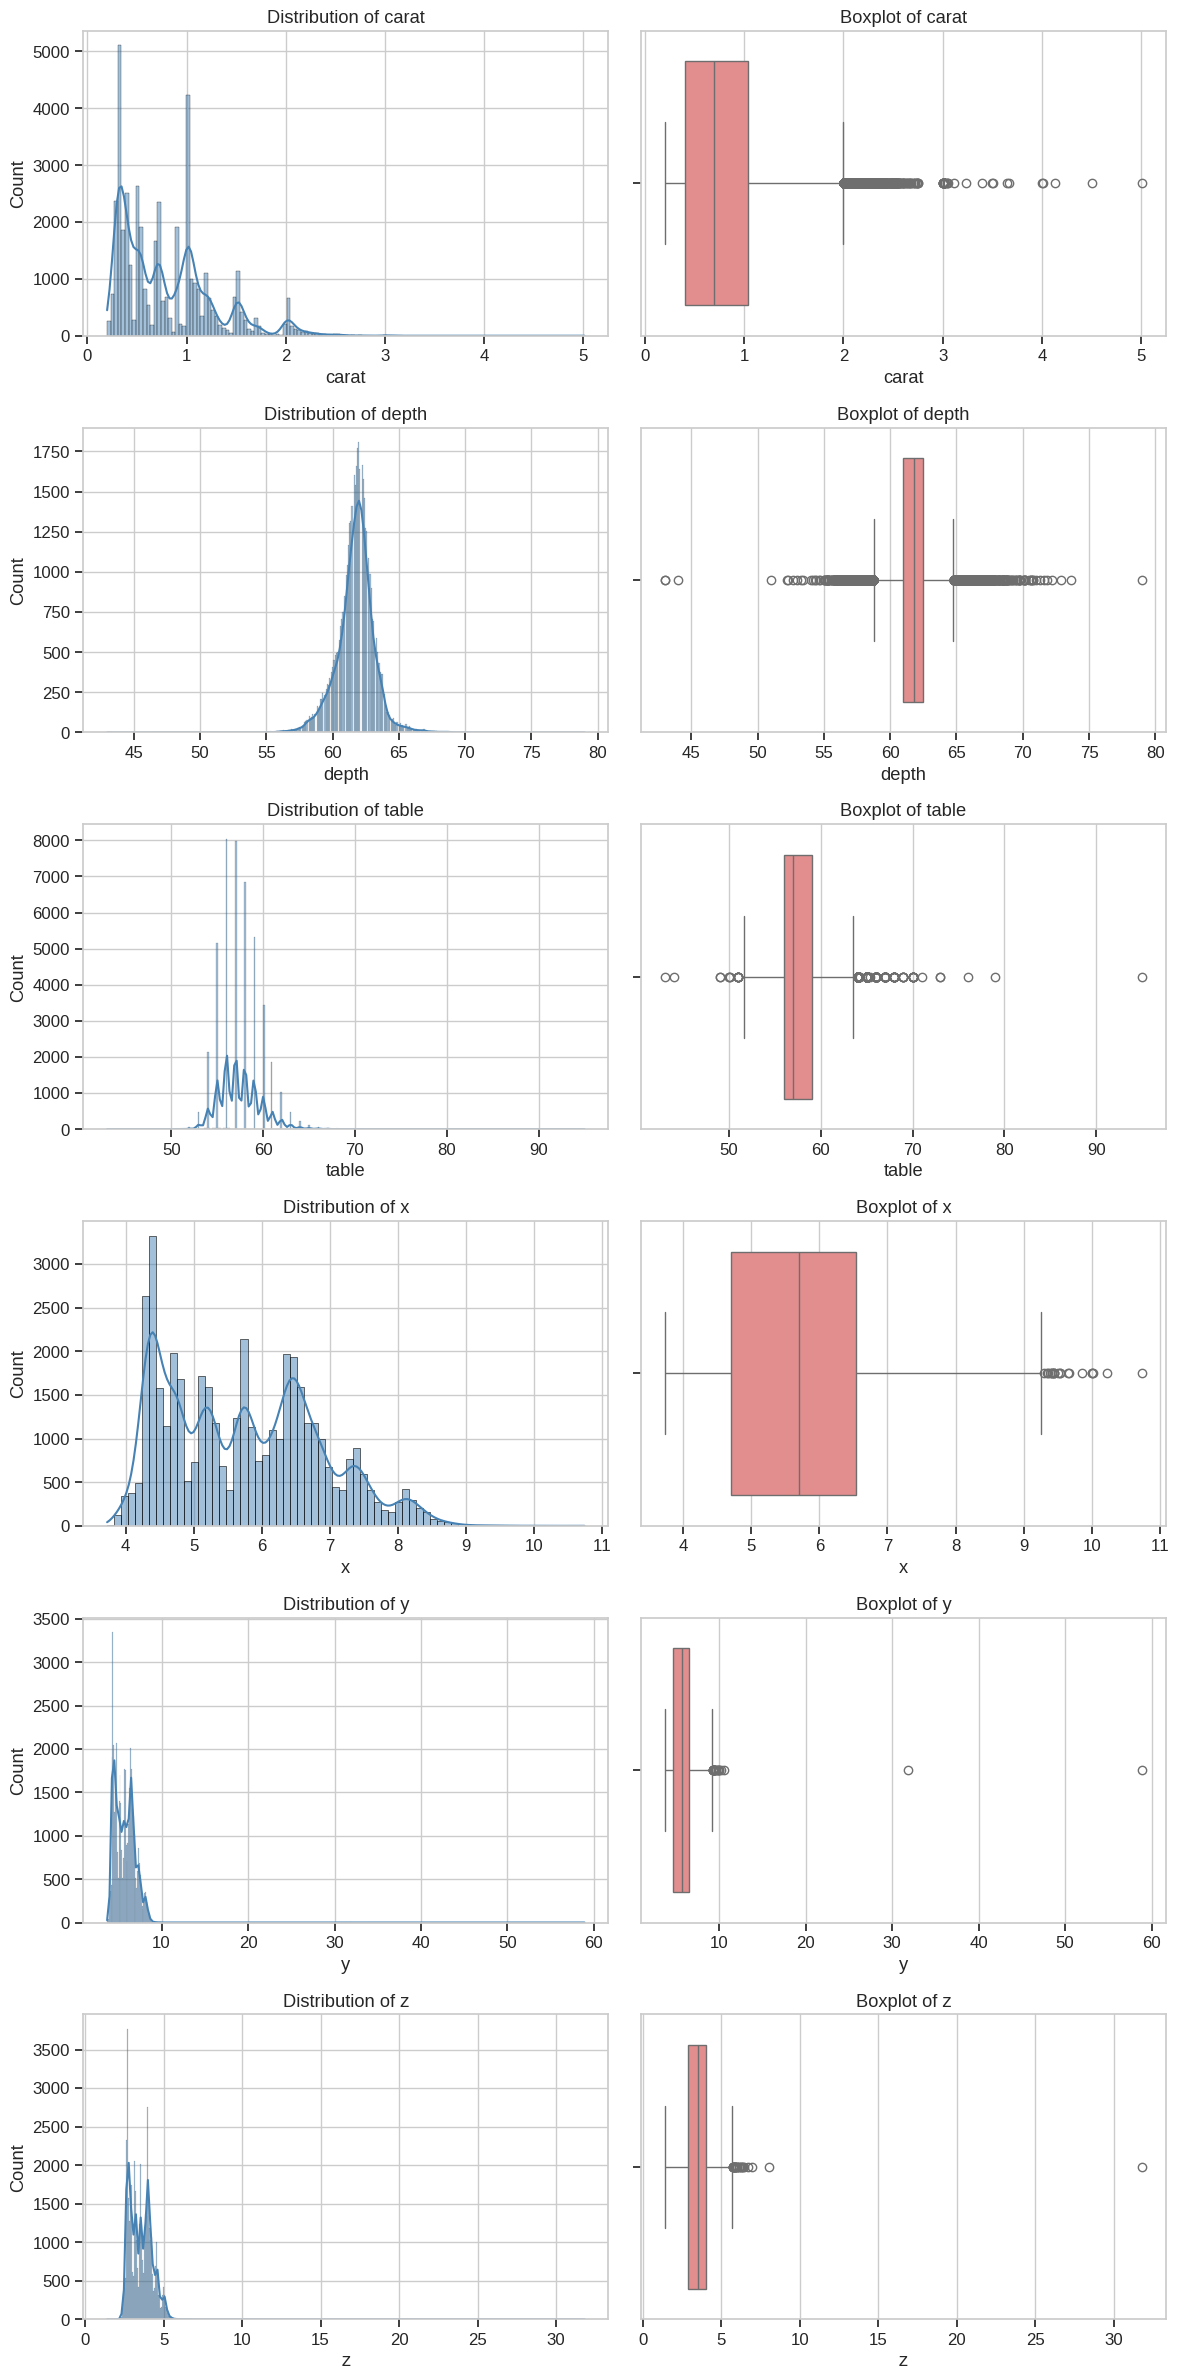

In [2]:
# ==============================================================================
# 2.A REMOVE NON-PHYSICAL DATA
# ==============================================================================
# Filter out the erroneous rows using the inverted mask
df_train_clean = df_train_clean[~errors_mask].reset_index(drop=True)
print(f"Dataset shape after removing non-physical data: {df_train_clean.shape}")

# ==============================================================================
# 2.B IDENTIFY OUTLIERS (DISTRIBUTIONS)
# ==============================================================================
def plot_distributions(df: pd.DataFrame, numerical_features: list):
    """
    Plots histograms and boxplots for numerical features to visually identify outliers.
    """
    n_features = len(numerical_features)
    fig, axes = plt.subplots(n_features, 2, figsize=(12, 4 * n_features))
    
    for i, col in enumerate(numerical_features):
        # Histogram
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
        axes[i, 0].set_title(f'Distribution of {col}')
        
        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
        axes[i, 1].set_title(f'Boxplot of {col}')
        
    plt.tight_layout()
    plt.show()

# Select purely numerical features for initial distribution analysis
# Excluding categorical ones (cut, color, clarity) and target (price)
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
plot_distributions(df_train_clean, num_cols)

* **Extreme Anomalies:** Variables `y` (width) and `z` (depth) display extreme outliers (values near 30mm and 60mm). Given the mean dimensions of a standard diamond, these are likely structural data entry errors that will distort spatial machine learning models.
* **Skewness & Multimodality:** The features `carat` and `x` are heavily right-skewed and multimodal, corresponding to standard commercial cutting weights. 
* **Tails:** `table` and `depth` exhibit roughly normal distributions but with significant heavy tails on both ends.

Because the spatial and weight distributions are heavily skewed and contain extreme magnitudes, relying on the mean and standard deviation (Z-score method) would be statistically flawed, as these metrics are sensitive to outliers. Instead, we will implement the **Interquartile Range (IQR)** method. IQR relies on the median and quartiles, making it mathematically robust for identifying true outliers in non-Gaussian distributions.

Total IQR-based outlier instances flagged: 4150


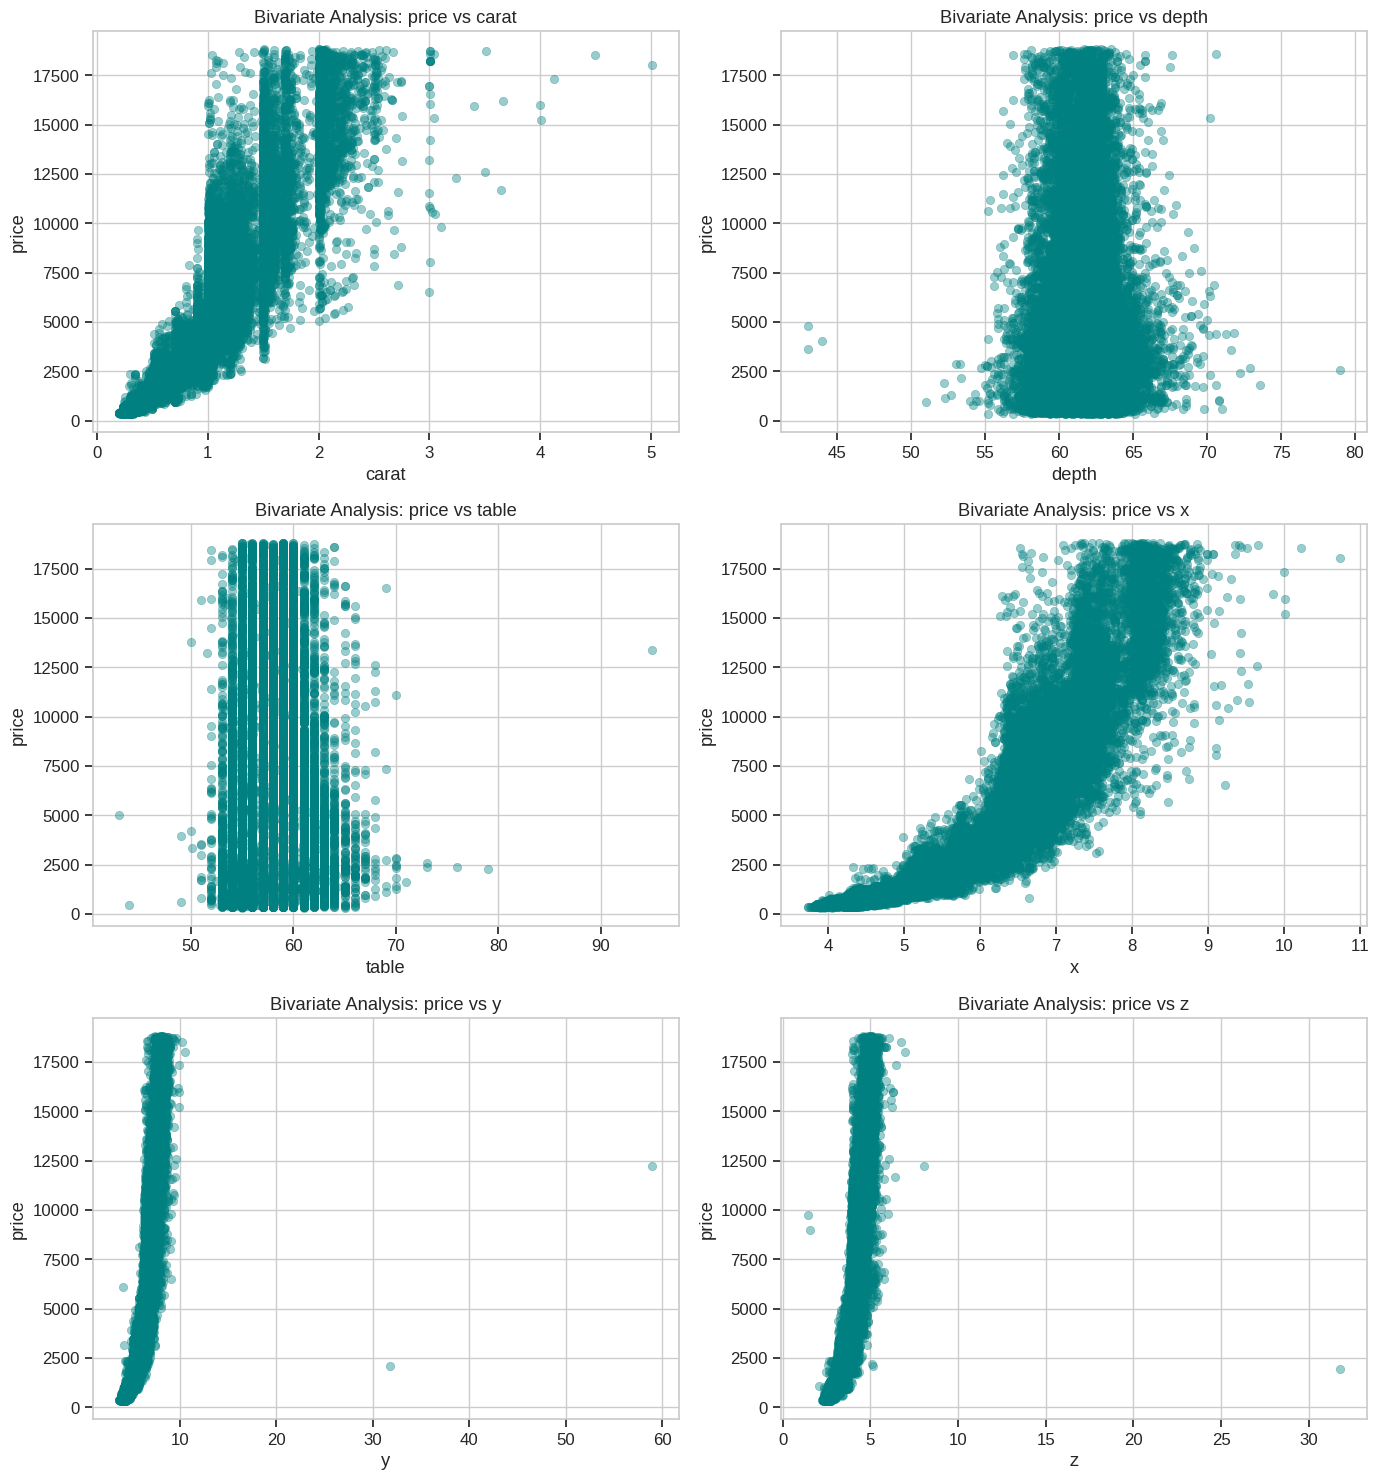

In [3]:
# ==============================================================================
# 2.B IDENTIFY OUTLIERS (IQR METHOD) & 2.D PREPARE OUTLIER TABLE
# ==============================================================================
# First, ensure the 'train_ids' series is perfectly aligned with the clean dataset
train_ids_clean = train_ids[~errors_mask].reset_index(drop=True)

outlier_records = []
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

#identification using Interquartile Range (IQR)
for col in num_cols:
    Q1 = df_train_clean[col].quantile(0.25)
    Q3 = df_train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create mask for values outside the [Q1 - 1.5*IQR, Q3 + 1.5*IQR] interval
    outlier_mask = (df_train_clean[col] < lower_bound) | (df_train_clean[col] > upper_bound)
    outlier_indices = df_train_clean[outlier_mask].index
    
    # Append the findings to our tracking list
    for idx in outlier_indices:
        outlier_records.append({
            'id': train_ids_clean.iloc[idx],
            'attribute': col,
            'value': df_train_clean.loc[idx, col],
            'reason': f'Out of IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]'
        })

# Convert to DataFrame to track all mathematical outliers
df_outliers = pd.DataFrame(outlier_records)
print(f"Total IQR-based outlier instances flagged: {len(df_outliers)}")

# ==============================================================================
# 2.C IDENTIFY OUTLIERS (ATTRIBUTE VS TARGET)
# ==============================================================================
def plot_price_scatter(df: pd.DataFrame, numerical_features: list, target: str = 'price'):
    """
    Generates scatter plots to visually identify bivariate outliers (feature vs target).
    """
    n_features = len(numerical_features)
    rows = (n_features + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numerical_features):
        sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.4, color='teal', edgecolor=None)
        axes[i].set_title(f'Bivariate Analysis: {target} vs {col}')
        
    # Hide any unused subplots if the number of features is odd
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

# Execute bivariate visualization
plot_price_scatter(df_train_clean, num_cols)

* **Non-linear Relationships:** `carat`, `x`, `y`, and `z` display exponential/polynomial relationship with `price`.
* **Multivariate Influence:** The high variance in price for higher carat weights (a 3-carat diamond priced low) is likely explained by poor categorical attributes (cut, color, clarity), which non-linear models (MLNN-BP, k-NN) could will capture.
* **Extreme Structural Errors:** The bivariate plots for `y` and `z` reveal isolated data points with massive physical dimensions (y > 20, z > 20) but relatively low prices. These are undeniable data entry errors that break geometric constraints.

The IQR method flagged 4150 univariate outliers (~9.4% of the dataset). Dropping these would result in catastrophic data loss, stripping the model of its ability to predict high-end luxury diamonds. These are naturally occurring heavy-tailed distributions.
Therefore, our strategy:
1. **Keep** the mathematically flagged IQR outliers, as the upcoming logarithmic transformation of the target variable will inherently manage this variance.
2. **Manually flag and drop** the extreme bivariate spatial errors (y > 20 and z > 20), as they are physically strange and will severely skew distance-based (k-NN) and linear (MLR) algorithms.

In [4]:
# ==============================================================================
# 2.D & 2.E: END OUTLIER TABLE AND EXECUTE HANDLING strat
# ==============================================================================

#identify bivariate extreme structural errors
bivariate_mask = (df_train_clean['y'] > 20) | (df_train_clean['z'] > 20)
bivariate_indices = df_train_clean[bivariate_mask].index

#Add them to outlier tracking table
for idx in bivariate_indices:
    outlier_records.append({
        'id': train_ids_clean.iloc[idx],
        'attribute': 'y/z',
        'value': f"y={df_train_clean.loc[idx, 'y']}, z={df_train_clean.loc[idx, 'z']}",
        'reason': 'Extreme bivariate spatial error (y or z > 20mm)'
    })

df_outliers = pd.DataFrame(outlier_records)
print(f"Total outliers tracked (Univariate + Bivariate): {len(df_outliers)}")

# Display sample of the table (combining some IQR and the Bivariate errors)
display(df_outliers)

#Drop ONLY the extreme bivariate errors
df_train_ready = df_train_clean[~bivariate_mask].reset_index(drop=True)
print(f"\nShape after dropping extreme bivariate errors: {df_train_ready.shape}")

Total outliers tracked (Univariate + Bivariate): 4153


,id,attribute,value,reason
0,79,carat,2.36,"Out of IQR bounds: [-0.56, 2.00]"
1,84,carat,2.17,"Out of IQR bounds: [-0.56, 2.00]"
2,158,carat,2.01,"Out of IQR bounds: [-0.56, 2.00]"
3,181,carat,2.02,"Out of IQR bounds: [-0.56, 2.00]"
4,205,carat,2.08,"Out of IQR bounds: [-0.56, 2.00]"
...,...,...,...,...
4148,40623,z,5.98,"Out of IQR bounds: [1.22, 5.73]"
4149,41889,z,6.03,"Out of IQR bounds: [1.22, 5.73]"
4150,10263,y/z,"y=5.15, z=31.8",Extreme bivariate spatial error (y or z > 20mm)
4151,19146,y/z,"y=58.9, z=8.06",Extreme bivariate spatial error (y or z > 20mm)



Shape after dropping extreme bivariate errors: (43981, 10)


In [5]:
# ==============================================================================
# 2.F ORDINAL ENCODING OF CATEGORICAL VARIABLES
# ==============================================================================
from sklearn.preprocessing import StandardScaler

# Define dictionaries based on the semantic order provided
cut_map = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_map = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_map = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

df_train_ready['cut'] = df_train_ready['cut'].map(cut_map)
df_train_ready['color'] = df_train_ready['color'].map(color_map)
df_train_ready['clarity'] = df_train_ready['clarity'].map(clarity_map)

# ==============================================================================
# 2.G STANDARDIZATION OF ATTRIBUTES (except X, Y, Z, PRICE)
# ==============================================================================
cols_to_standardize = ['carat', 'depth', 'table', 'cut', 'color', 'clarity']
scaler = StandardScaler()

#apply standard scaling
df_train_ready[cols_to_standardize] = scaler.fit_transform(df_train_ready[cols_to_standardize])

# ==============================================================================
# 2.H JOINT MIN-MAX SCALING FOR X, Y, Z [-1, 1]
# ==============================================================================
#find global min and max across all three spatial dimensions
global_min = df_train_ready[['x', 'y', 'z']].min().min()
global_max = df_train_ready[['x', 'y', 'z']].max().max()

#apply joint scaling formula: 2 * (val - min) / (max - min) - 1
for col in ['x', 'y', 'z']:
    df_train_ready[col] = 2 * ((df_train_ready[col] - global_min) / (global_max - global_min)) - 1

# ==============================================================================
# 2.I LOG TRANSFORMATION AND [0.1, 0.9] SCALING OF TARGET
# ==============================================================================
#calc logarithm
log_price_raw = np.log(df_train_ready['price'])

# Min-Max Scaling to [0.1, 0.9]
min_log = log_price_raw.min()
max_log = log_price_raw.max()

df_train_ready['log_price'] = 0.1 + 0.8 * ((log_price_raw - min_log) / (max_log - min_log))

# ==============================================================================
# 2.J CREATE BINARY CLASSIFICATION TARGET
# ==============================================================================
df_train_ready['high_price'] = (df_train_ready['price'] >= 2500).astype(int)


print("Pre-processing complete. Final dataset sample:")
display(df_train_ready)

Pre-processing complete. Final dataset sample:


,carat,cut,color,clarity,depth,table,x,y,z,price,log_price,high_price
0,-0.565350,-0.809650,1.522764,-0.033634,1.013088,-0.649353,-0.209003,-0.198285,-0.607717,1601,0.413928,0
1,-1.008897,0.084807,-0.827918,-0.033634,0.453710,0.246672,-0.367631,-0.374062,-0.721329,648,0.235513,0
2,-0.079559,0.979263,-1.415588,-0.639886,0.034177,-0.201340,-0.039657,-0.052519,-0.526259,2399,0.493702,0
3,0.448473,-1.704107,-0.827918,-0.033634,-0.665046,1.590710,0.076099,0.091104,-0.459807,5229,0.647397,1
4,-0.142923,0.979263,-1.415588,0.572618,0.243943,-1.545378,-0.065380,-0.058950,-0.532690,2167,0.473640,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43976,0.237260,-0.809650,-0.240247,0.572618,-0.595124,-1.545378,0.041801,0.065380,-0.476956,4590,0.621687,1
43977,-1.030018,0.084807,1.522764,0.572618,-1.504114,0.246672,-0.356913,-0.363344,-0.740622,877,0.295205,0
43978,-0.839927,-1.704107,-1.415588,-0.639886,1.502544,-0.201340,-0.294748,-0.303323,-0.661308,765,0.268254,0
43979,1.504539,0.084807,0.347423,-0.033634,0.174021,2.038723,0.273312,0.247588,-0.333333,13771,0.838407,1


**Dimensionality & Indexing:** The dataset retains exactly **43981** rows. The index has been properly reset, ensuring no misalignment for future cross-validation splits.
**Standardization (Z-score):** Columns like `carat`, `cut`, `color`, `clarity`, `depth`, and `table` now display values both positive and negative (-0.565, 1.522). This confirms they are centered around mu=0 with a variance of sigma^2=1.
**Joint Spatial Scaling:** The spatial features x, y, and z are represented as negative fractions (-0.209, -0.607). Given that the global minimum was strictly >0 and the global maximum was around 10.74, the formula '2 * ({val - min}/{max - min}) - 1' projects them into the [-1, 1] interval while maintaining their geometric proportions.
**Target Variables:** `log_price` falls within the [0.1, 0.9] bounds. The binary classification logic is sound. For instance, Row 3 (`price` = 5229) maps to `high_price` = 1, and Row 0 (`price` = 1601) maps to 0.

In [6]:
# ==============================================================================
# SAVE PREPROCESSED TRAINING DATA
# ==============================================================================
output_path = '/home/jovyan/work/AAMD-Task-SupervisedLearning/data/diamonds-train-preprocessed.csv'
df_train_ready.to_csv(output_path, index=False)
print(f"Preprocessed training data successfully saved to: {output_path}")

#store the transformation parameters needed for the test set
transformation_params = {
    'scaler': scaler,  #fitted StandardScaler object
    'spatial_min': global_min,
    'spatial_max': global_max,
    'log_price_min': min_log,
    'log_price_max': max_log,
    'cut_map': cut_map,
    'color_map': color_map,
    'clarity_map': clarity_map
}

Preprocessed training data successfully saved to: /home/jovyan/work/AAMD-Task-SupervisedLearning/data/diamonds-train-preprocessed.csv


###Test Set Preprocessing and Data Leakage Prevention
The test dataset must strictly represent unseen, real-world data. To maintain mathematical consistency and prevent **data leakage**, we cannot recalculate statistical transformation parameters (such as mean, standard deviation, or global minimums/maximums) on the test set.

If we were to use `fit_transform()` on the test data, we would establish a new mathematical baseline, which differs from what the model learned during training, thereby invalidating our final evaluation. Instead, we must exclusively use the `transform()` method, applying the exact parameters (mu, sigma, min, max) and ordinal dictionaries extracted solely from the training set. This guarantees that both datasets share the exact same standardized feature space.

In [7]:
def preprocess_test_data(df_test_raw, params):
    """
    Applies the exact same transformations to the test set using parameters 
    learned from the training set to prevent data leakage.
    """
    # Drop 'id' and create a working copy
    df_test = df_test_raw.copy()
    test_ids = df_test['id']
    df_test = df_test.drop(columns=['id'])

    # Ordinal Encoding, using the same maps
    df_test['cut'] = df_test['cut'].map(params['cut_map'])
    df_test['color'] = df_test['color'].map(params['color_map'])
    df_test['clarity'] = df_test['clarity'].map(params['clarity_map'])

    # Standardization (using the FITTED scaler from training)
    cols_to_std = ['carat', 'depth', 'table', 'cut', 'color', 'clarity']
    df_test[cols_to_std] = params['scaler'].transform(df_test[cols_to_std])

    # Joint spatial scaling [-1, 1] (using training min/max)
    s_min, s_max = params['spatial_min'], params['spatial_max']
    for col in ['x', 'y', 'z']:
        df_test[col] = 2 * ((df_test[col] - s_min) / (s_max - s_min)) - 1

    # Target transformations: log_price and high_price
    #price is the target, transform it only to evaluate later
    log_p = np.log(df_test['price'])
    p_min, p_max = params['log_price_min'], params['log_price_max']
    df_test['log_price'] = 0.1 + 0.8 * ((log_p - p_min) / (p_max - p_min))

    df_test['high_price'] = (df_test['price'] >= 2500).astype(int)

    return df_test, test_ids

#load raw test data
df_test_raw = pd.read_csv('/home/jovyan/work/AAMD-Task-SupervisedLearning/data/diamonds-test.csv')

# Process it using the stored parameters
df_test_ready, test_ids = preprocess_test_data(df_test_raw, transformation_params)

print(f"Test set preprocessed successfully. Shape: {df_test_ready.shape}")
display(df_test_ready)

output_path2 = '/home/jovyan/work/AAMD-Task-SupervisedLearning/data/diamonds-test-ready.csv'
df_test_ready.to_csv(output_path2, index=False)
print(f"Test preprocessed set data successfully saved to: {output_path2}")

Test set preprocessed successfully. Shape: (9940, 12)


,carat,cut,color,clarity,depth,table,x,y,z,price,log_price,high_price
0,0.617444,0.979263,-0.240247,1.178870,0.523632,-0.649353,0.099678,0.108253,-0.423365,8282,0.738107,1
1,-0.206287,-0.809650,0.347423,-0.639886,-1.364269,1.142698,-0.069668,-0.052519,-0.560557,2196,0.476262,0
2,2.560604,-1.704107,-1.415588,-0.639886,-2.063492,1.142698,0.470525,0.453376,-0.264737,16731,0.876813,1
3,-1.114504,0.979263,0.347423,2.391375,0.034177,-1.097366,-0.414791,-0.399786,-0.751340,760,0.266960,0
4,-0.544228,0.084807,1.522764,-0.639886,0.383788,1.142698,-0.183280,-0.191854,-0.607717,1715,0.427496,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9935,3.870125,0.979263,-2.003259,-1.246138,0.243943,-0.201340,0.590568,0.601286,-0.123258,16914,0.878958,1
9936,0.638565,0.979263,0.347423,1.178870,-0.385357,-0.649353,0.129689,0.123258,-0.427653,9817,0.771647,1
9937,3.067515,0.979263,-1.415588,-1.246138,-0.734968,-0.649353,0.528403,0.519829,-0.193998,11104,0.795947,1
9938,0.469595,-0.809650,0.935094,2.391375,1.222855,0.246672,0.076099,0.054662,-0.434084,10710,0.788820,1


Test preprocessed set data successfully saved to: /home/jovyan/work/AAMD-Task-SupervisedLearning/data/diamonds-test-ready.csv
